# Finding enzymes that act on similar reactions to a simple reaction 

In [24]:
import sys
from enzymetk import ReactionDist
from enzymetk import Save
import pandas as pd
import os

label = 'PyrOx'
data_folder = 'manuscript/'
rxn_smiles = 'OO.C1CCCCC1>>OC2CCCCC2.O'
reaction_df = pd.read_pickle(os.path.join(data_folder, f'enzymemap_v2_brenda2023_reactions.pkl'))

id_col = 'id'
output_dir = 'Julia_output/'
reactions = (reaction_df << (ReactionDist(id_col, 'unmapped', rxn_smiles) >> Save(f'{output_dir}reaction_similarity_{label}.pkl')))

100%|█████| 62896/62896 [00:49<00:00, 1278.06it/s]


In [25]:
import sys
from enzymetk import ReactionDist
from enzymetk import Save
import pandas as pd
import os

reactions = pd.read_pickle(f'{output_dir}reaction_similarity_{label}.pkl')

In [26]:
top_substrate_distance_df = reactions.sort_values('TanimotoSimilarity', ascending=False)
top_substrate_distance_df

,id,QuerySmiles,unmapped,TanimotoSimilarity,RusselSimilarity,CosineSimilarity
5955,1.11.2.1_38070,C1CNCC1>>OC2CNCC2,C1CCOC1.OO>>O.OC1CCOC1,0.406250,0.006348,0.577920
8661,3.8.1.5_274287,C1CNCC1>>OC2CNCC2,ClC1CCCC1.O>>Cl.OC1CCCC1,0.382353,0.006348,0.554322
5963,1.11.2.1_37965,C1CNCC1>>OC2CNCC2,C1CCCCC1.OO>>O.OC1CCCCC1,0.382353,0.006348,0.554322
7221,3.8.1.5_274424,C1CNCC1>>OC2CNCC2,ClCCCCl.O>>Cl.OCCCCl,0.322581,0.004883,0.489116
41847,3.8.1.5_274437,C1CNCC1>>OC2CNCC2,ClCCCCCl.O>>Cl.OCCCCCl,0.315789,0.005859,0.483494
...,...,...,...,...,...,...
1376,4.1.2.10_281038,C1CNCC1>>OC2CNCC2,Cc1ccc([C@@H](O)C#N)c(C)c1>>C#N.Cc1ccc(C=O)c(C)c1,0.000000,0.000000,0.000000
1378,4.1.2.10_281036,C1CNCC1>>OC2CNCC2,COc1cccc([C@@H](O)C#N)c1>>C#N.COc1cccc(C=O)c1,0.000000,0.000000,0.000000
41720,3.8.1.8_274592,C1CNCC1>>OC2CNCC2,CC(C)N=c1nc(Cl)[nH]c(=O)[nH]1.O>>CC(C)N.O=c1nc...,0.000000,0.000000,0.000000
29799,4.5.1.1_298222,C1CNCC1>>OC2CNCC2,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1>>Cl.ClC...,0.000000,0.000000,0.000000


In [27]:
top_substrate_distance_df['unmapped'].values[0]

'C1CCOC1.OO>>O.OC1CCOC1'

In [28]:
top_substrate_distance_df = top_substrate_distance_df.head(20)

# Get the most similar substrates now

# Check what enzymes these connect to 

In [29]:
from tqdm import tqdm
from ast import literal_eval

data_folder = 'manuscript/'

# Read in the embedded datasets and each of the processed datasets from CARE (we expect you to just download the task1 datasets and put them in processed datasets)
protein_encoding_df = pd.read_pickle(os.path.join(data_folder, 'protein.pkl'))

# Read in the reaction df 
reaction_df = pd.read_pickle(os.path.join(data_folder, 'enzymemap_v2_brenda2023_reactions.pkl'))
products_df = pd.read_pickle(os.path.join(data_folder, 'enzymemap_v2_brenda2023_products.pkl'))
substrates_df = pd.read_pickle(os.path.join(data_folder, 'enzymemap_v2_brenda2023_substrates.pkl'))

# Now convert to dictionaries to map between 
ec_grps = reaction_df.groupby('ec_num')['unmapped'].apply(list).reset_index(name='unmapped')
ec_to_reaction = dict(zip(ec_grps['ec_num'].values, ec_grps['unmapped'].values))

# Ensure that the substrates are read in as a list.
reaction_df.substrates = reaction_df.substrates.apply(literal_eval)
reaction_df.products = reaction_df.products.apply(literal_eval)

reaction_to_substrates = dict(zip(reaction_df['unmapped'].values, reaction_df['substrates'].values))
reaction_to_products = dict(zip(reaction_df['unmapped'].values, reaction_df['products'].values))



ec_dict = ec_to_reaction
rows = []
substrate_rows = []
for entry, seq, ecs in tqdm(protein_encoding_df[['Entry', 'Sequence', 'EC number']].values):
    ecs = ecs.split('|')
    count_pos = 0
    for ec in ecs:
        if ec_dict.get(ec):
            reactions = ec_dict.get(ec)
            for reaction in reactions:
                rows.append([entry, ec, reaction])
df = pd.DataFrame(rows, columns=['Entry', 'EC number', 'Reaction'])

# Get the top ones
top_substrates = top_substrate_distance_df['unmapped'].values
top_df = df[df['Reaction'].isin(top_substrates)]
top_df

100%|██| 261254/261254 [00:03<00:00, 85006.99it/s]


,Entry,EC number,Reaction
11139,B9W4V6,1.11.2.1,C1CCOC1.OO>>O.OC1CCOC1
11147,B9W4V6,1.11.2.1,C1CCCCC1.OO>>O.OC1CCCCC1
11242,B9W4V6,1.11.2.1,C1CCOCC1.OO>>O.OC1CCCOC1
14578,D4Z2G1,3.8.1.5,ClCCCCl.O>>Cl.OCCCCl
14579,D4Z2G1,3.8.1.5,ClCC(Br)CBr.O>>Cl.OCC(Br)CBr
...,...,...,...
2652478,Q9XB14,3.8.1.5,ClC1CCCC1.O>>Cl.OC1CCCC1
2652493,Q9XB14,3.8.1.5,CCCCCCl.O>>CCCCCO.Cl
2652503,Q9XB14,3.8.1.5,ClC1CCCCC1.O>>Cl.OC1CCCCC1
2652513,Q9XB14,3.8.1.5,O.OCCCCCl>>Cl.OCCCCO


In [30]:
top_df = df[df['Reaction'].isin(top_substrates)]
top_df

,Entry,EC number,Reaction
11139,B9W4V6,1.11.2.1,C1CCOC1.OO>>O.OC1CCOC1
11147,B9W4V6,1.11.2.1,C1CCCCC1.OO>>O.OC1CCCCC1
11242,B9W4V6,1.11.2.1,C1CCOCC1.OO>>O.OC1CCCOC1
14578,D4Z2G1,3.8.1.5,ClCCCCl.O>>Cl.OCCCCl
14579,D4Z2G1,3.8.1.5,ClCC(Br)CBr.O>>Cl.OCC(Br)CBr
...,...,...,...
2652478,Q9XB14,3.8.1.5,ClC1CCCC1.O>>Cl.OC1CCCC1
2652493,Q9XB14,3.8.1.5,CCCCCCl.O>>CCCCCO.Cl
2652503,Q9XB14,3.8.1.5,ClC1CCCCC1.O>>Cl.OC1CCCCC1
2652513,Q9XB14,3.8.1.5,O.OCCCCCl>>Cl.OCCCCO


In [31]:
reaction_df = pd.read_csv('manuscript/enzymemap_v2_brenda2023.csv')
reaction_df

,rxn_idx,mapped,unmapped,orig_rxn_text,rule,rule_id,source,steps,quality,natural,organism,protein_refs,protein_db,ec_num
0,0,[CH3:1][CH:2]=[O:3].[H+].[NH2:4][C:5](=[O:6])[...,CC=O.NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O...,acetaldehyde + NADH + H+ = ethanol + NAD+ {r},[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[#6:5]-[#6:6]-1.[...,0,direct,single,0.991708,True,Saccharomyces cerevisiae,[],NaN,1.1.1.1
1,0,[CH3:1][CH2:2][OH:3].[NH2:4][C:5](=[O:6])[c:7]...,CCO.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP...,acetaldehyde + NADH + H+ = ethanol + NAD+ {r},[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[#6:5]-[#6:6]-1.[...,0,direct reversed,single,0.991708,True,Saccharomyces cerevisiae,[],NaN,1.1.1.1
2,1,[CH3:1][CH:2]=[O:3].[H+].[NH2:4][C:5](=[O:6])[...,CC=O.NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O...,acetaldehyde + NADH + H+ = ethanol + NAD+ {r},[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[#6:5]-[#6:6]-1.[...,0,direct,single,0.991708,True,Ogataea angusta,['H9ZGN0'],uniprot,1.1.1.1
3,1,[CH3:1][CH2:2][OH:3].[NH2:4][C:5](=[O:6])[c:7]...,CCO.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP...,acetaldehyde + NADH + H+ = ethanol + NAD+ {r},[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[#6:5]-[#6:6]-1.[...,0,direct reversed,single,0.991708,True,Ogataea angusta,['H9ZGN0'],uniprot,1.1.1.1
4,2,[CH3:1][CH:2]=[O:3].[H+].[NH2:4][C:5](=[O:6])[...,CC=O.NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O...,acetaldehyde + NADH + H+ = ethanol + NAD+ {r},[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[#6:5]-[#6:6]-1.[...,0,direct,single,0.991708,True,Chlamydomonas reinhardtii,['Q1RS84'],uniprot,1.1.1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349453,324556,[CH3:1][C:2]([CH3:3])=[CH:4][CH2:5][O:6][P:7](...,CC(C)=CCOP(=O)(O)OP(=O)(O)O.Nc1ncnc2c1ncn2[C@@...,ATP + dimethylallyl diphosphate = dimethylally...,[#6:1]-[#8:2].[#8:3]>>[#6:1]-[#8:3].[#8:2],279,direct,single,0.416667,False,Escherichia virus T4,[],NaN,6.5.1.3
349454,324557,[CH3:1][C:2]([CH3:3])=[CH:4][CH2:5][CH2:6]/[C:...,CC(C)=CCC/C(C)=C/COP(=O)(O)OP(=O)(O)O.Nc1ncnc2...,ATP + geranyl diphosphate = geranyl-triphospho...,[#6:1]-[#8:2].[#8:3]>>[#6:1]-[#8:3].[#8:2],279,direct,single,0.416667,False,Escherichia virus T4,[],NaN,6.5.1.3
349455,324558,[CH3:1][C:2]([CH3:3])=[CH:4][CH2:5][CH2:6]/[C:...,CC(C)=CCC/C(C)=C/COP(=O)(O)OP(=O)(O)OP(=O)(O)O...,ATP + geranyl triphosphate = geranyl-tetraphos...,[#8:1].[#8:2]-[#15:3]>>[#8:2].[#8:1]-[#15:3],281,direct,single,0.583333,False,Escherichia virus T4,[],NaN,6.5.1.3
349456,324559,[CH2:1]=[C:2]([CH3:3])[CH2:4][CH2:5][O:6][P:7]...,C=C(C)CCOP(=O)(O)OP(=O)(O)O.Nc1ncnc2c1ncn2[C@@...,ATP + isopentenyl diphosphate = adenosine 5'-i...,[#6:1]-[#8:2].[#8:3]>>[#6:1]-[#8:3].[#8:2],279,direct,single,0.416667,False,Escherichia virus T4,[],NaN,6.5.1.3


# Check what the substrates look like

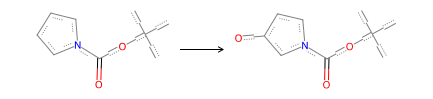

In [32]:
from rdkit import Chem
from rdkit.Chem import Draw
import pubchempy
from rdkit.Chem import Draw
from rdkit.Chem import rdChemReactions
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D, rdDepictor
import rdkit

#rxn_smiles = 'O=C(N(C)C)NC1=CC=C(Cl)C=C1'

rxn = rdChemReactions.ReactionFromSmarts(rxn_smiles)
drawer = rdMolDraw2D.MolDraw2DSVG(-1,-1)
dopts = drawer.drawOptions()
dopts.bondLineWidth = 1.0 # default is 2.0
drawer.DrawReaction(rxn)
drawer.FinishDrawing()
import IPython.display
i = IPython.display.SVG(drawer.GetDrawingText())
display(i)


In [33]:
set(top_df['Reaction'].values)

{'C1CCC2OC2C1.C1CCC2OC2C1.O.O>>O[C@@H]1CCCC[C@H]1O.O[C@H]1CCCC[C@@H]1O',
 'C1CCC2OC2C1.O>>OC1CCCCC1O',
 'C1CCC2OC2C1.O>>OC1CCCC[C@@H]1O',
 'C1CCCCC1.OO>>O.OC1CCCCC1',
 'C1CCOC1.OO>>O.OC1CCOC1',
 'C1CCOCC1.OO>>O.OC1CCCOC1',
 'CCCCCCl.O>>CCCCCO.Cl',
 'ClC1CCCC1.O>>Cl.OC1CCCC1',
 'ClC1CCCCC1.O>>Cl.OC1CCCCC1',
 'ClCC(Br)CBr.O>>Cl.OCC(Br)CBr',
 'ClCC1CO1.O>>OCC(O)CCl',
 'ClCCCCCl.O>>Cl.OCCCCCl',
 'ClCCCCl.O>>Cl.OCCCCl',
 'NC(=O)C1CCNCC1.O>>N.O=C(O)C1CCNCC1',
 'O.OCCCCCl>>Cl.OCCCCO',
 'O=C(O)[C@@H]1C[C@@H](O)CN1>>O=C(O)[C@H]1C[C@@H](O)CN1',
 'O=C(O)[C@@H]1C[C@H](O)CN1>>O=C(O)[C@H]1C[C@H](O)CN1',
 'O=C(O)[C@H]1C[C@@H](O)CN1>>O=C(O)[C@@H]1C[C@@H](O)CN1',
 'O=C(O)[C@H]1C[C@@H](O)CN1>>O=C(O)[C@@H]1C[C@H](O)CN1',
 'O=C(O)[C@H]1C[C@H](O)CN1>>O=C(O)[C@@H]1C[C@H](O)CN1'}

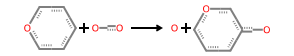

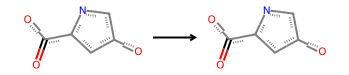

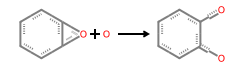

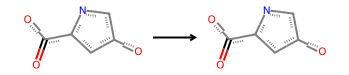

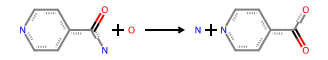

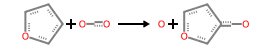

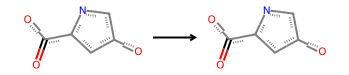

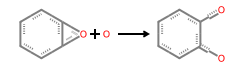

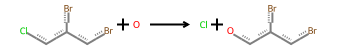

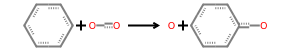

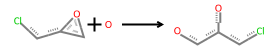

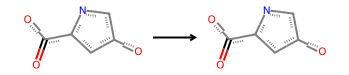

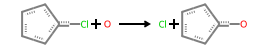

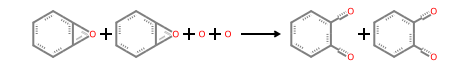

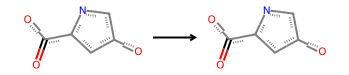

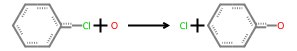

In [34]:
import IPython.display

names = []
smiles_to_name = {}
ms = []


for c in set(top_df['Reaction'].values):
    rxn = rdChemReactions.ReactionFromSmarts(c)
    #rxn = remove_atom_mapping(rxn)
    drawer = rdMolDraw2D.MolDraw2DSVG(-1,-1)
    dopts = drawer.drawOptions()
    dopts.addAtomIndices = False  # This is the key line
    dopts.bondLineWidth = 2.0 # default is 2.0
    drawer.DrawReaction(rxn)
    drawer.FinishDrawing()
    i = IPython.display.SVG(drawer.GetDrawingText())
    display(i)

In [35]:
from sciutil import SciUtil

u = SciUtil()

protein_info = pd.read_csv(f'{data_folder}uniprotkb_reviewed_true_2025_17_02.tsv', sep='\t')
# Filter for "short" bacterial sequences
proteins = protein_encoding_df[protein_encoding_df['Entry'].isin(top_df['Entry'].values)]
proteins

/tmp/ipykernel_908215/1361229108.py:5: DtypeWarning: Columns (19,21,22,29) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_info = pd.read_csv(f'{data_folder}uniprotkb_reviewed_true_2025_17_02.tsv', sep='\t')


,Unnamed: 0,Entry,Sequence,EC number,Residue_0index,Residue_1index,active_site_residue_counts,Polarity,temperature,Length,Mass,active_embedding,esm_embedding
1212,2445,B9W4V6,MKYFPLFPTLVFAARVVAFPAYASLAGLSQQELDAIIPTLEAREPG...,1.11.2.1,NaN,NaN,0,0.000000,25.0,371,40652,[],"[0.02570082, -0.022711424, -0.075440496, 0.070..."
1473,3027,D4Z2G1,MSLGAKPFGEKKFIEIKGRRMAYIDEGTGDPILFQHGNPTSSYLWR...,3.8.1.5,107|131|271,108|132|272,3,0.333333,29.0,296,33108,"[[-0.15200026, -0.5066463, -0.26020625, 0.4458...","[0.029870717, -0.081150696, -0.08873079, 0.011..."
4590,11343,P07099,MWLEILLTSVLGFAIYWFISRDKEETLPLEDGWWGPGTRSAAREDD...,3.3.2.9,225|373|430,226|374|431,3,0.333333,NaN,455,52949,"[[-0.393658, -0.58187836, -0.17852125, 0.27778...","[0.032242, -0.079502165, -0.022326464, 0.09968..."
4679,11543,P07687,MWLELVLASLLGFVIYWFVSRDKEETLPLGDGWWGPGSKPSAKEDE...,3.3.2.9,225|373|430,226|374|431,3,0.333333,NaN,455,52582,"[[-0.40503302, -0.56672543, -0.19915819, 0.272...","[0.035518613, -0.07616603, -0.037745353, 0.097..."
6824,16912,P22643,MINAIRTPDQRFSNLDQYPFSPNYLDDLPGYPGLRAHYLDEGNSDA...,3.8.1.5,123|259|288,124|260|289,3,0.000000,30.0,310,35144,"[[-0.3375141, -0.66011584, -0.17871529, 0.2493...","[0.04224108, -0.05869383, -0.070032656, 0.0251..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
257183,525283,Q92WS1,MATHTFSCIDGHTCGNPVRLVSGGGPRLEGANMLEKRAHFLKEFDW...,5.1.1.8,89|252,90|253,2,1.000000,27.0,333,36243,"[[-0.15998709, -0.08425452, -0.049347118, 0.16...","[-0.026954368, -0.01977509, 0.08422373, -0.046..."
257218,525363,Q938B4,MPGSEPYGRLQYREINGKRMAYIDEARGDAIVFQHGNPSSSYLWRN...,3.8.1.5,106|130|271,107|131|272,3,0.333333,36.0,311,34979,"[[-0.14217696, -0.4589568, -0.23537695, 0.4143...","[0.032398157, -0.05500859, -0.0878114, 0.00741..."
257676,526851,Q98C03,MSSKANPPQPVATAPKRSQIPILDSTMSYVEAGASGPTVLFLHGNP...,3.8.1.5,109|133|277,110|134|278,3,0.333333,30.0,309,34201,"[[-0.21813701, -0.43615952, -0.11665998, 0.316...","[0.018118074, -0.06966649, -0.10233011, -0.009..."
257984,527684,Q9A919,MDVLRTPDERFEGLADWSFAPHYTEVTDADGTALRIHHVDEGPKDQ...,3.8.1.5,122|248|277,123|249|278,3,0.000000,30.0,302,33155,"[[-0.4935949, -0.7490478, -0.10693064, 0.28282...","[0.031887025, -0.12221351, -0.12329114, 0.0344..."


# Add information e.g. about the organism 

In [36]:
length_filter = 300
proteins = proteins[proteins['Length'] < length_filter]

# Finally select those that come from bacteria for obvious reasons...
protein_all_info = protein_info[protein_info['Entry'].isin(proteins['Entry'].values)]
# 2157 or 2 (archaea or bacteria)
protein_all_info['superkingdom'] = [c.split(',')[1].split(' ')[1].strip() for c in protein_all_info['Taxonomic lineage (Ids)'].values]

u.dp(['Superkingdom'])
print(protein_all_info['superkingdom'].value_counts())
protein_all_info = protein_all_info[protein_all_info['superkingdom'].isin(['2', '2157'])]

u.dp(['Cofactors'])
print(protein_all_info['Cofactor'].value_counts())
#protein_all_info = protein_all_info[protein_all_info['Cofactor'].isna()]

u.dp(['Subunits'])
print(protein_all_info['Subunit structure'].value_counts())
protein_all_info['Subunit'] = ['Monomer or Homodimer' if (isinstance(s, (int, float, complex)) or 'Monomer' in s or 'Homodimer' in s) else 'Complex' for s in protein_all_info['Subunit structure'].values]
protein_all_info = protein_all_info[protein_all_info['Subunit'] == 'Monomer or Homodimer']



--------------------------------------------------------------------------------
                                 Superkingdom	                                  
--------------------------------------------------------------------------------
superkingdom
2    12
Name: count, dtype: int64
--------------------------------------------------------------------------------
                                   Cofactors	                                   
--------------------------------------------------------------------------------
Series([], Name: count, dtype: int64)
--------------------------------------------------------------------------------
                                   Subunits	                                    
--------------------------------------------------------------------------------
Subunit structure
SUBUNIT: Monomer. {ECO:0000250}.                                                6
SUBUNIT: Monomer. {ECO:0000269|PubMed:12773375, ECO:0000269|PubMed:9748436}.    1
SUBU

/tmp/ipykernel_908215/1606490865.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_all_info['superkingdom'] = [c.split(',')[1].split(' ')[1].strip() for c in protein_all_info['Taxonomic lineage (Ids)'].values]


In [37]:
protein_all_info

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Organism (ID),Taxonomic lineage (Ids),Mass,...,Transmembrane,Glycosylation,Post-translational modification,Disulfide bond,PubMed ID,DOI ID,PDB,BRENDA,superkingdom,Subunit
3027,D4Z2G1,reviewed,LINB_SPHIU,"Haloalkane dehalogenase (EC 3.8.1.5) (1,3,4,6-...",linB SJA_C1-19590,Sphingobium indicum (strain DSM 16413 / CCM 72...,296,452662,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33108,...,NaN,NaN,NaN,NaN,7691794; 20817768; 10464214; 9293022; 10100638...,10.1128/jb.175.20.6403-6410.1993; 10.1128/jb.0...,1CV2;1D07;1G42;1G4H;1G5F;1IZ7;1IZ8;1K5P;1K63;1...,3.8.1.5;,2,Monomer or Homodimer
109564,Q9ZAG3,reviewed,LIMA_RHOER,"Limonene-1,2-epoxide hydrolase (EC 3.3.2.8)",limA,Rhodococcus erythropolis (Arthrobacter picolin...,149,1833,"131567 (no rank), 2 (superkingdom), 1783272 (k...",16521,...,NaN,NaN,NaN,NaN,9827564; 9748436; 12773375,10.1016/s0014-5793(98)01322-2; 10.1128/jb.180....,1NU3;1NWW;4R9K;4R9L;4XBT;4XBX;4XBY;4XDV;4XDW;5...,3.3.2.8;,2,Monomer or Homodimer
111074,A0A1L5BTC1,reviewed,LINB_SPHIB,"Haloalkane dehalogenase (EC 3.8.1.5) (1,3,4,6-...",linB SIDU_17345,Sphingobium indicum (strain DSM 16412 / CCM 72...,296,861109,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33230,...,NaN,NaN,NaN,NaN,12450824; 22843598,10.1128/aem.68.12.6021-6028.2002; 10.1128/jb.0...,NaN,NaN,2,Monomer or Homodimer
195698,P0A3G2,reviewed,DHAA_RHORH,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus rhodochrous,293,1829,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33246,...,NaN,NaN,NaN,NaN,9025284,10.1099/00221287-143-1-109,2V9Z;3FBW;3RK4;3SK0;4E46;4F5Z;4F60;4FWB;4WCV;5...,3.8.1.5;,2,Monomer or Homodimer
195699,P0A3G3,reviewed,DHAA_RHOSO,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus sp,293,1831,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33246,...,NaN,NaN,NaN,NaN,12089046,10.1128/aem.68.7.3582-3587.2002,3FWH;3G9X;4HZG;4KAA;4KAC;4KAF;4KAJ;5Y2X;5Y2Y;6...,3.8.1.5;,2,Monomer or Homodimer
195700,P0A3G4,reviewed,DHAA_PSEPV,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Pseudomonas pavonaceae,293,47881,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33246,...,NaN,NaN,NaN,NaN,9687453; 10735862,10.1128/aem.64.8.2931-2936.1998; 10.1128/jb.18...,8OE2;,NaN,2,Monomer or Homodimer
212319,P59336,reviewed,DHAA_RHOSD,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus sp. (strain TDTM0003),294,269091,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33331,...,NaN,NaN,NaN,NaN,10587433,10.1021/bi9913855,1BN6;1BN7;1CQW;,NaN,2,Monomer or Homodimer
219680,P9WMS1,reviewed,DHMA2_MYCTU,Haloalkane dehalogenase 2 (EC 3.8.1.5),dhmA2 Rv1833c MTCY1A11.10,Mycobacterium tuberculosis (strain ATCC 25618 ...,286,83332,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32151,...,NaN,NaN,NaN,NaN,9634230; 21969609,10.1038/31159; 10.1074/mcp.m111.011445,NaN,NaN,2,Monomer or Homodimer
282837,Q75SP7,reviewed,RSAM_PSESP,(R)-stereoselective amidase (EC 3.5.1.100),ramA,Pseudomonas sp,274,306,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",30128,...,NaN,NaN,NaN,NaN,15066183; 15955066,10.1111/j.1432-1033.2004.04069.x; 10.1111/j.17...,NaN,3.5.1.100;,2,Monomer or Homodimer
372497,B2HJU9,reviewed,DHMA_MYCMM,Haloalkane dehalogenase (EC 3.8.1.5),dhmA MMAR_3472,Mycobacterium marinum (strain ATCC BAA-535 / M),297,216594,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32818,...,NaN,NaN,NaN,NaN,18403782,10.1101/gr.075069.107,NaN,NaN,2,Monomer or Homodimer


# Now print out the most similar reactions again

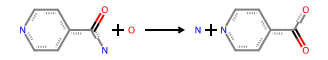

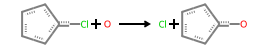

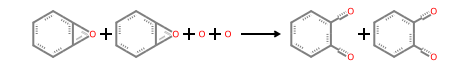

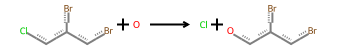

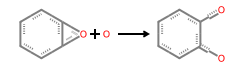

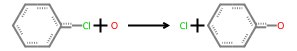

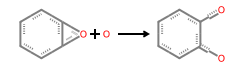

In [38]:
top_rxn = top_df[top_df['Entry'].isin(protein_all_info['Entry'].values)]

names = []
smiles_to_name = {}
ms = []

for c in set(top_rxn['Reaction'].values):
    rxn = rdChemReactions.ReactionFromSmarts(c)
    #rxn = remove_atom_mapping(rxn)
    drawer = rdMolDraw2D.MolDraw2DSVG(-1,-1)
    dopts = drawer.drawOptions()
    dopts.addAtomIndices = False  # This is the key line
    dopts.bondLineWidth = 2.0 # default is 2.0
    drawer.DrawReaction(rxn)
    drawer.FinishDrawing()
    i = IPython.display.SVG(drawer.GetDrawingText())
    display(i)

In [39]:
protein_all_info['EC number'].value_counts()

EC number
3.8.1.5      10
3.3.2.8       1
3.5.1.100     1
Name: count, dtype: int64

In [40]:
protein_all_info = protein_all_info[~protein_all_info['Organism'].str.contains('tuberculosis')]
protein_all_info

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Organism (ID),Taxonomic lineage (Ids),Mass,...,Transmembrane,Glycosylation,Post-translational modification,Disulfide bond,PubMed ID,DOI ID,PDB,BRENDA,superkingdom,Subunit
3027,D4Z2G1,reviewed,LINB_SPHIU,"Haloalkane dehalogenase (EC 3.8.1.5) (1,3,4,6-...",linB SJA_C1-19590,Sphingobium indicum (strain DSM 16413 / CCM 72...,296,452662,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33108,...,NaN,NaN,NaN,NaN,7691794; 20817768; 10464214; 9293022; 10100638...,10.1128/jb.175.20.6403-6410.1993; 10.1128/jb.0...,1CV2;1D07;1G42;1G4H;1G5F;1IZ7;1IZ8;1K5P;1K63;1...,3.8.1.5;,2,Monomer or Homodimer
109564,Q9ZAG3,reviewed,LIMA_RHOER,"Limonene-1,2-epoxide hydrolase (EC 3.3.2.8)",limA,Rhodococcus erythropolis (Arthrobacter picolin...,149,1833,"131567 (no rank), 2 (superkingdom), 1783272 (k...",16521,...,NaN,NaN,NaN,NaN,9827564; 9748436; 12773375,10.1016/s0014-5793(98)01322-2; 10.1128/jb.180....,1NU3;1NWW;4R9K;4R9L;4XBT;4XBX;4XBY;4XDV;4XDW;5...,3.3.2.8;,2,Monomer or Homodimer
111074,A0A1L5BTC1,reviewed,LINB_SPHIB,"Haloalkane dehalogenase (EC 3.8.1.5) (1,3,4,6-...",linB SIDU_17345,Sphingobium indicum (strain DSM 16412 / CCM 72...,296,861109,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33230,...,NaN,NaN,NaN,NaN,12450824; 22843598,10.1128/aem.68.12.6021-6028.2002; 10.1128/jb.0...,NaN,NaN,2,Monomer or Homodimer
195698,P0A3G2,reviewed,DHAA_RHORH,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus rhodochrous,293,1829,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33246,...,NaN,NaN,NaN,NaN,9025284,10.1099/00221287-143-1-109,2V9Z;3FBW;3RK4;3SK0;4E46;4F5Z;4F60;4FWB;4WCV;5...,3.8.1.5;,2,Monomer or Homodimer
195699,P0A3G3,reviewed,DHAA_RHOSO,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus sp,293,1831,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33246,...,NaN,NaN,NaN,NaN,12089046,10.1128/aem.68.7.3582-3587.2002,3FWH;3G9X;4HZG;4KAA;4KAC;4KAF;4KAJ;5Y2X;5Y2Y;6...,3.8.1.5;,2,Monomer or Homodimer
195700,P0A3G4,reviewed,DHAA_PSEPV,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Pseudomonas pavonaceae,293,47881,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33246,...,NaN,NaN,NaN,NaN,9687453; 10735862,10.1128/aem.64.8.2931-2936.1998; 10.1128/jb.18...,8OE2;,NaN,2,Monomer or Homodimer
212319,P59336,reviewed,DHAA_RHOSD,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus sp. (strain TDTM0003),294,269091,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33331,...,NaN,NaN,NaN,NaN,10587433,10.1021/bi9913855,1BN6;1BN7;1CQW;,NaN,2,Monomer or Homodimer
282837,Q75SP7,reviewed,RSAM_PSESP,(R)-stereoselective amidase (EC 3.5.1.100),ramA,Pseudomonas sp,274,306,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",30128,...,NaN,NaN,NaN,NaN,15066183; 15955066,10.1111/j.1432-1033.2004.04069.x; 10.1111/j.17...,NaN,3.5.1.100;,2,Monomer or Homodimer
372497,B2HJU9,reviewed,DHMA_MYCMM,Haloalkane dehalogenase (EC 3.8.1.5),dhmA MMAR_3472,Mycobacterium marinum (strain ATCC BAA-535 / M),297,216594,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32818,...,NaN,NaN,NaN,NaN,18403782,10.1101/gr.075069.107,NaN,NaN,2,Monomer or Homodimer
434322,P64304,reviewed,DHMA2_MYCBO,Haloalkane dehalogenase 2 (EC 3.8.1.5),dhmA2 BQ2027_MB1864C,Mycobacterium bovis (strain ATCC BAA-935 / AF2...,286,233413,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32151,...,NaN,NaN,NaN,NaN,12788972; 28385856,10.1073/pnas.1130426100; 10.1128/genomea.00157-17,NaN,NaN,2,Monomer or Homodimer


# Cluster based on sequence similarity

In [41]:
from enzymetk.similarity_mmseqs_step import MMseqs
from enzymetk.save_step import Save
import pandas as pd

id_col = 'Entry'
seq_col = 'Sequence'

clustered = (protein_all_info << (MMseqs(id_col, seq_col, method='cluster', args=['--min-seq-id', '0.5', '-c', '0.8', '--cov-mode', '0']) >> Save(f'{output_dir}{label}_mmseqs_files.pkl')))
clustered

--------------------------------------------------------------------------------
Running command	mmseqs easy-cluster /tmp/tmp0p06dtwd/seqs.fasta /tmp/tmp0p06dtwd/clusterRes /tmp/tmp0p06dtwd/tmp --min-seq-id 0.5 -c 0.8 --cov-mode 0	
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
                                    Output:	                                    
--------------------------------------------------------------------------------
Create directory /tmp/tmp0p06dtwd/tmp
easy-cluster /tmp/tmp0p06dtwd/seqs.fasta /tmp/tmp0p06dtwd/clusterRes /tmp/tmp0p06dtwd/tmp --min-seq-id 0.5 -c 0.8 --cov-mode 0 

MMseqs Version:                     	18.8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target se

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Organism (ID),Taxonomic lineage (Ids),Mass,...,Glycosylation,Post-translational modification,Disulfide bond,PubMed ID,DOI ID,PDB,BRENDA,superkingdom,Subunit,mmseqs_representative_cluster_seq
0,D4Z2G1,reviewed,LINB_SPHIU,"Haloalkane dehalogenase (EC 3.8.1.5) (1,3,4,6-...",linB SJA_C1-19590,Sphingobium indicum (strain DSM 16413 / CCM 72...,296,452662,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33108,...,NaN,NaN,NaN,7691794; 20817768; 10464214; 9293022; 10100638...,10.1128/jb.175.20.6403-6410.1993; 10.1128/jb.0...,1CV2;1D07;1G42;1G4H;1G5F;1IZ7;1IZ8;1K5P;1K63;1...,3.8.1.5;,2,Monomer or Homodimer,A0A1L5BTC1
1,Q9ZAG3,reviewed,LIMA_RHOER,"Limonene-1,2-epoxide hydrolase (EC 3.3.2.8)",limA,Rhodococcus erythropolis (Arthrobacter picolin...,149,1833,"131567 (no rank), 2 (superkingdom), 1783272 (k...",16521,...,NaN,NaN,NaN,9827564; 9748436; 12773375,10.1016/s0014-5793(98)01322-2; 10.1128/jb.180....,1NU3;1NWW;4R9K;4R9L;4XBT;4XBX;4XBY;4XDV;4XDW;5...,3.3.2.8;,2,Monomer or Homodimer,Q9ZAG3
2,A0A1L5BTC1,reviewed,LINB_SPHIB,"Haloalkane dehalogenase (EC 3.8.1.5) (1,3,4,6-...",linB SIDU_17345,Sphingobium indicum (strain DSM 16412 / CCM 72...,296,861109,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33230,...,NaN,NaN,NaN,12450824; 22843598,10.1128/aem.68.12.6021-6028.2002; 10.1128/jb.0...,NaN,NaN,2,Monomer or Homodimer,A0A1L5BTC1
3,P0A3G2,reviewed,DHAA_RHORH,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus rhodochrous,293,1829,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33246,...,NaN,NaN,NaN,9025284,10.1099/00221287-143-1-109,2V9Z;3FBW;3RK4;3SK0;4E46;4F5Z;4F60;4FWB;4WCV;5...,3.8.1.5;,2,Monomer or Homodimer,P0A3G2
4,P0A3G3,reviewed,DHAA_RHOSO,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus sp,293,1831,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33246,...,NaN,NaN,NaN,12089046,10.1128/aem.68.7.3582-3587.2002,3FWH;3G9X;4HZG;4KAA;4KAC;4KAF;4KAJ;5Y2X;5Y2Y;6...,3.8.1.5;,2,Monomer or Homodimer,P0A3G2
5,P0A3G4,reviewed,DHAA_PSEPV,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Pseudomonas pavonaceae,293,47881,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",33246,...,NaN,NaN,NaN,9687453; 10735862,10.1128/aem.64.8.2931-2936.1998; 10.1128/jb.18...,8OE2;,NaN,2,Monomer or Homodimer,P0A3G2
6,P59336,reviewed,DHAA_RHOSD,Haloalkane dehalogenase (EC 3.8.1.5),dhaA,Rhodococcus sp. (strain TDTM0003),294,269091,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33331,...,NaN,NaN,NaN,10587433,10.1021/bi9913855,1BN6;1BN7;1CQW;,NaN,2,Monomer or Homodimer,P0A3G2
7,Q75SP7,reviewed,RSAM_PSESP,(R)-stereoselective amidase (EC 3.5.1.100),ramA,Pseudomonas sp,274,306,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",30128,...,NaN,NaN,NaN,15066183; 15955066,10.1111/j.1432-1033.2004.04069.x; 10.1111/j.17...,NaN,3.5.1.100;,2,Monomer or Homodimer,Q75SP7
8,B2HJU9,reviewed,DHMA_MYCMM,Haloalkane dehalogenase (EC 3.8.1.5),dhmA MMAR_3472,Mycobacterium marinum (strain ATCC BAA-535 / M),297,216594,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32818,...,NaN,NaN,NaN,18403782,10.1101/gr.075069.107,NaN,NaN,2,Monomer or Homodimer,B2HJU9
9,P64304,reviewed,DHMA2_MYCBO,Haloalkane dehalogenase 2 (EC 3.8.1.5),dhmA2 BQ2027_MB1864C,Mycobacterium bovis (strain ATCC BAA-935 / AF2...,286,233413,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32151,...,NaN,NaN,NaN,12788972; 28385856,10.1073/pnas.1130426100; 10.1128/genomea.00157-17,NaN,NaN,2,Monomer or Homodimer,P64304


In [42]:
clustered_seqs = pd.read_pickle(f'{output_dir}{label}_mmseqs_files.pkl')
print(len(clustered_seqs['mmseqs_representative_cluster_seq'].value_counts()))
clustered_seqs['mmseqs_representative_cluster_seq'].value_counts()

6


mmseqs_representative_cluster_seq
P0A3G2        4
A0A1L5BTC1    2
Q9ZAG3        1
Q75SP7        1
B2HJU9        1
P64304        1
Name: count, dtype: int64

## We'll order the cluster centers

In [43]:
cluster_centres = set(clustered_seqs['mmseqs_representative_cluster_seq'].value_counts().index)
protein_all_info = protein_all_info[protein_all_info['Entry'].isin(cluster_centres)]
protein_all_info['Organism'].value_counts()

Organism
Rhodococcus erythropolis (Arthrobacter picolinophilus)                  1
Sphingobium indicum (strain DSM 16412 / CCM 7286 / MTCC 6364 / B90A)    1
Rhodococcus rhodochrous                                                 1
Pseudomonas sp                                                          1
Mycobacterium marinum (strain ATCC BAA-535 / M)                         1
Mycobacterium bovis (strain ATCC BAA-935 / AF2122/97)                   1
Name: count, dtype: int64

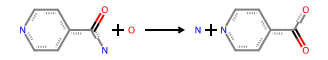

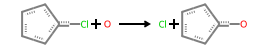

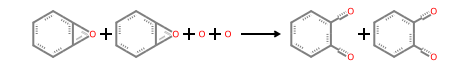

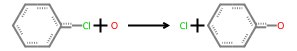

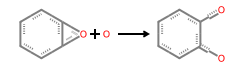

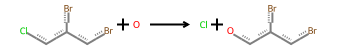

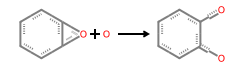

In [44]:
top_rxn = top_df[top_df['Entry'].isin(protein_all_info['Entry'].values)]

names = []
smiles_to_name = {}
ms = []

for c in set(top_rxn['Reaction'].values):
    rxn = rdChemReactions.ReactionFromSmarts(c)
    #rxn = remove_atom_mapping(rxn)
    drawer = rdMolDraw2D.MolDraw2DSVG(-1,-1)
    dopts = drawer.drawOptions()
    dopts.addAtomIndices = False  # This is the key line
    dopts.bondLineWidth = 2.0 # default is 2.0
    drawer.DrawReaction(rxn)
    drawer.FinishDrawing()
    i = IPython.display.SVG(drawer.GetDrawingText())
    display(i)

# Codon optimize the sequences 

I use IDT codon optimization since I'll be ordeirng through them: https://www.idtdna.com/pages/tools/codon-optimization-tool

Click `select all` and order all sequences then you can copy and paste them out... tedious I know but they have some magic that is better if you use their tool...

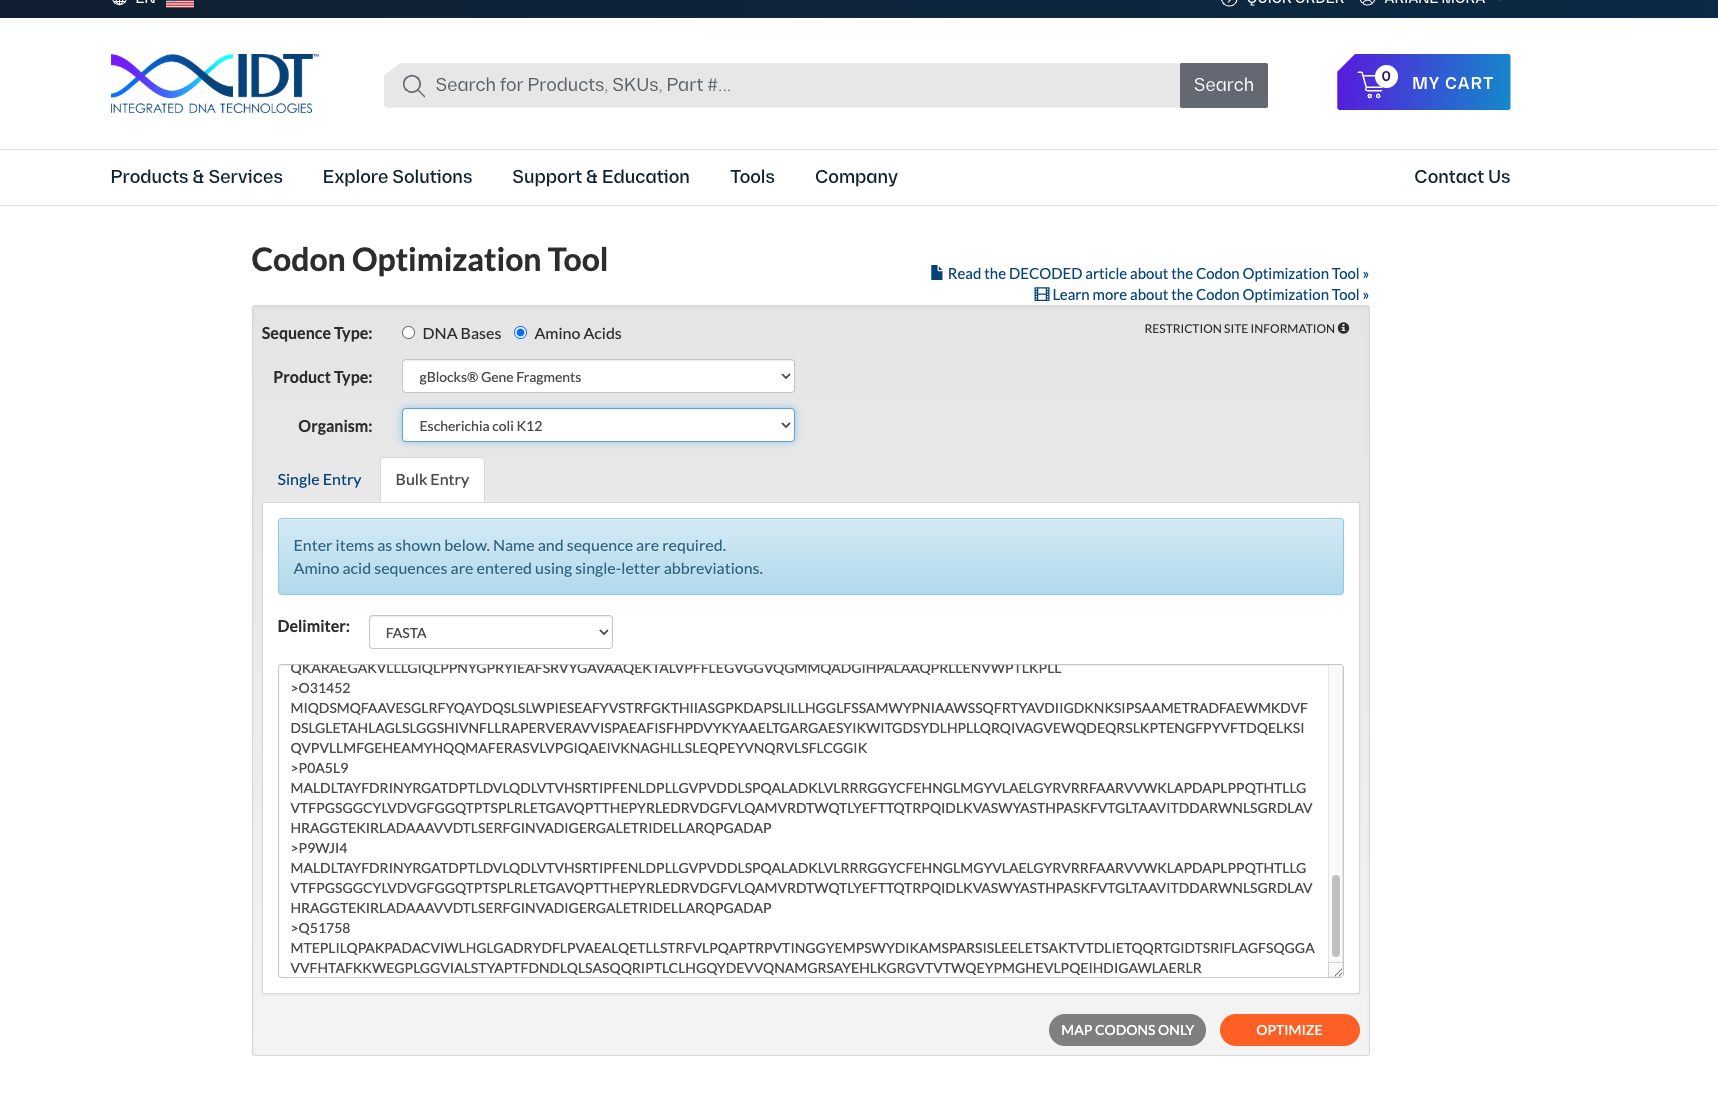

In [138]:
protein_all_info.to_csv(f'enzymes_to_order_{label}.csv')

In [137]:
for entry, seq in protein_all_info[['Entry', 'Sequence']].values:
    print(f'>{entry}\n{seq}')

>P95442
MTTTLYTGFHQLVTGDVAGTVLNGVDILVRDGEIIGLGPDLPRTLAPIGVGQEQGVEVVNCRGLTAYPGLINTHHHFFQAFVRNLAPLDWTQLDVLAWLRKIYPVFALVDEDCIYHSTVVSMAELIKHGCTTAFDHQYNYSRRGGPFLVDRQFDAANLLGLRFHAGRGCITLPMAEGSTIPDAMRESTDTFLADCERLVSRFHDPRPFAMQRVVVAPSSPVIAYPETFVESARLARHLGVSLHTHLGEGETPAMVARFGERSLDWCENRGFVGPDVWLAHGWEFTAADIARLAATGTGVAHCPAPVFLVGAEVTDIPAMAAAGVRVGFGVDGHASNDSSNLAECIRLAYLLQCLKASERQHPVPAPYDFLRMATQGGADCLNRPDLGALAVGRAADFFAVDLNRIEYIGANHDPRSLPAKVGFSGPVDMTVINGKVVWRNGEFPGLDEMELARAADGVFRRVIYGDPLVAALRRGTGVTPC
>P42428
MIVDLPLRRIQQFARLGAKHQSSVLIRLHTKGGIVGIGESITPCGPWWSGDSVEAIQATINHYLAPLVVGEPALDASRIMAKLHGRVAGNAFAKAGIEMALLDAVGKIVDAPIHVLLGGRFRDRLSVAWPLATGDVNQEVDEAFRMLEAGKAGAFKLKMGALPLAQDLRRALAIAKELEGKASLRVDPNEAWDEPTTMRALAPLEAAGVEIIEQPVARWNLDAMARIHRQARSMLLIDEGVQSLHDASEVVKRAAAGLVSLKIMKTGGMRPARAMADIANAGGMHVYMGTFLETSIGTAANMQLAASIESLPYGGEVIGPLLIEEDLCEVPAVYKEHALWLPEGPGLGIRLDENQVRRFARASSQRIDRHSA
>Q6Q3H0
MINAIRTPDQRFSNLDQYPFSPNYLDDLPGYPGLRAHYLDEGNSDAEDVFLCLHGEPTWSYLYRKMIPVFAESGARVIAPDFFGFGKSDKPVDEEDYTFEFHRNFLLALIERLDLRNITLV

In [139]:
optimized = {'P95442': 'ATGACCACGACACTTTACACGGGGTTCCATCAATTAGTCACTGGGGATGTAGCGGGCACAGTACTTAACGGTGTAGATATTCTGGTTCGCGACGGCGAGATCATTGGATTGGGACCCGATTTACCGCGTACGTTAGCTCCGATTGGTGTAGGACAAGAACAGGGGGTTGAAGTAGTGAATTGCCGCGGACTTACTGCATACCCAGGTCTGATCAACACCCACCATCACTTCTTCCAAGCTTTCGTGCGTAATTTAGCACCGTTGGATTGGACTCAATTAGATGTACTGGCATGGCTTCGTAAAATCTACCCGGTTTTTGCTCTGGTCGACGAAGATTGTATTTACCATTCAACAGTTGTATCAATGGCCGAGTTAATCAAGCACGGCTGCACGACCGCTTTTGACCATCAGTACAACTATTCCCGTCGTGGTGGCCCTTTCCTGGTTGACCGTCAATTTGACGCCGCGAACCTGCTTGGTTTGCGTTTTCATGCAGGTCGTGGGTGTATTACCCTTCCAATGGCTGAGGGTAGCACGATTCCGGACGCAATGCGTGAGAGTACAGACACTTTTCTGGCTGACTGCGAACGTTTGGTCTCTCGTTTCCACGACCCACGTCCGTTCGCTATGCAACGCGTAGTAGTTGCGCCTTCTAGTCCGGTAATCGCTTATCCTGAAACATTCGTGGAGTCTGCACGCTTGGCCCGCCATTTGGGGGTAAGTTTGCATACACACCTGGGTGAAGGTGAAACTCCGGCGATGGTAGCGCGTTTTGGTGAGCGTTCACTTGACTGGTGCGAGAACCGCGGTTTTGTCGGGCCAGACGTTTGGCTGGCGCATGGATGGGAATTCACGGCAGCAGACATCGCCCGCTTGGCGGCCACAGGCACTGGCGTAGCTCATTGCCCAGCTCCGGTGTTTTTAGTGGGAGCAGAGGTTACCGACATTCCGGCGATGGCCGCCGCAGGTGTGCGCGTTGGTTTTGGGGTTGACGGTCATGCCTCCAATGATTCAAGTAACTTAGCCGAGTGCATCCGCCTGGCGTACCTTCTGCAATGTTTGAAAGCATCTGAGCGTCAACACCCCGTCCCAGCGCCGTACGATTTTCTGCGTATGGCCACGCAAGGCGGGGCCGATTGCCTGAACCGTCCCGATCTTGGGGCACTTGCGGTAGGACGTGCTGCCGACTTCTTTGCGGTCGATCTGAATCGCATTGAGTATATTGGAGCGAATCATGATCCTCGTTCACTTCCAGCCAAAGTTGGTTTTAGCGGTCCGGTAGACATGACCGTTATCAACGGAAAGGTGGTCTGGCGTAATGGAGAGTTCCCCGGTTTGGATGAAATGGAACTTGCGCGTGCGGCGGACGGCGTCTTCCGCCGTGTCATTTATGGAGATCCGCTTGTTGCAGCATTACGTCGTGGTACTGGTGTGACACCCTGT', 
             # interesting in DEHP as well?
              'P42428': 'ATGATCGTCGACTTACCATTACGTCGCATCCAACAATTCGCTCGCTTGGGAGCAAAGCATCAAAGCAGTGTGTTAATTCGTTTGCACACCAAAGGCGGCATTGTAGGAATCGGGGAAAGCATTACACCTTGTGGCCCATGGTGGTCGGGCGACTCTGTAGAAGCAATTCAAGCCACGATTAACCACTACCTGGCTCCTTTAGTTGTGGGGGAGCCCGCCTTGGATGCTTCTCGTATTATGGCAAAGTTACACGGTCGCGTTGCGGGAAATGCATTTGCAAAAGCTGGTATCGAAATGGCTTTACTGGACGCCGTTGGGAAAATTGTGGACGCACCGATTCACGTCTTGCTGGGTGGACGCTTCCGCGACCGTCTGTCGGTGGCGTGGCCACTTGCCACAGGCGATGTCAATCAGGAAGTCGATGAAGCTTTCCGTATGCTGGAAGCAGGTAAAGCAGGTGCATTCAAGCTGAAAATGGGCGCTTTACCATTAGCACAGGATCTGCGCCGCGCTCTGGCCATTGCCAAGGAACTTGAGGGAAAAGCGAGTCTGCGCGTTGACCCTAACGAGGCCTGGGACGAGCCCACTACGATGCGCGCATTAGCGCCGTTAGAGGCTGCCGGTGTGGAGATTATTGAGCAACCCGTCGCACGTTGGAACTTAGACGCAATGGCACGTATTCATCGCCAAGCACGTTCTATGTTACTGATTGATGAGGGTGTGCAAAGCTTACATGATGCTTCGGAGGTGGTAAAGCGTGCTGCCGCCGGTTTGGTCAGCTTGAAGATCATGAAAACGGGTGGTATGCGTCCAGCACGTGCAATGGCAGACATTGCGAACGCTGGTGGTATGCACGTCTATATGGGGACCTTCTTAGAAACTTCCATTGGGACTGCGGCTAATATGCAGCTTGCCGCCTCCATCGAGAGTTTGCCTTATGGCGGCGAAGTCATCGGGCCACTGTTGATTGAAGAAGATCTGTGCGAGGTGCCCGCGGTATATAAGGAACATGCCCTTTGGCTTCCTGAAGGTCCTGGTCTTGGCATTCGTTTGGATGAGAATCAAGTGCGCCGTTTCGCCCGCGCCTCGAGTCAACGTATTGATCGTCACTCCGCG', 
             'Q6Q3H0': 'ATGATTAATGCTATTCGTACTCCGGACCAGCGCTTTAGTAATCTTGACCAGTATCCCTTTTCTCCAAATTACTTAGATGATCTTCCAGGGTACCCTGGGCTTCGCGCACATTACCTGGACGAGGGCAATTCAGACGCTGAGGATGTCTTTTTATGCCTGCACGGGGAGCCTACATGGAGCTATCTTTATCGCAAGATGATTCCCGTCTTTGCAGAGTCCGGCGCTCGTGTAATTGCCCCTGATTTTTTTGGCTTTGGCAAATCCGACAAACCGGTTGATGAAGAGGACTACACTTTCGAGTTCCATCGCAACTTCTTATTGGCTCTGATTGAGCGTTTAGATTTGCGTAATATTACTTTGGTTGTGCAAGATTGGGGCGGGTTCTTGGGCCTGACGCTTCCAATGGCCGATCCCTCACGTTTCAAACGTCTTATTATTATGAACGCATGTCTTATGACAGATCCTGTCACCCAACCTGCTTTCTCCGCCTTCGTAACGCAGCCCGCAGATGGATTCACAGCTTGGAAATATGATCTTGTAACCCCCAGCGACCTGCGTTTGGACCAGTTCATGAAACGCTGGGCCCCAACACTTACAGAAGCGGAAGCCTCGGCGTATGCAGCGCCGTTTCCTGATACCAGTTACCAAGCTGGTGTCCGCAAGTTCCCAAAGATGGTCGCCCAGCGCGATCAGGCCTGCATCGACATTTCGACAGAGGCGATTAGTTTCTGGCAAAACGATTGGAATGGTCAAACTTTTATGGCGATTGGAATGAAAGATAAGTTATTGGGACCGGACGTCATGTACCCAATGAAGGCATTAATCAACGGGTGCCCGGAGCCATTGGAAATTGCAGACGCGGGACACTTTGTCCAGGAGTTTGGAGAGCAGGTGGCGCGTGAAGCTCTGAAACACTTCGCTGAGACTGAA',
             'Q9ZER0': 'ATGTCAGAGATCGGCACAGGCTTCCCCTTTGACCCCCATTATGTAGAGGTACTGGGAGAGCGTATGCACTATGTTGATGTGGGGCCTCGCGATGGAACGCCCGTATTATTCTTGCACGGAAATCCCACTTCATCCTATTTATGGCGTAATATCATCCCCCATGTCGCACCTTCTCATCGTTGTATTGCCCCCGATCTGATCGGTATGGGAAAATCGGATAAGCCGGACCTGGACTATTTTTTTGACGATCATGTTCGCTACCTGGATGCCTTCATCGAAGCTCTTGGTTTGGAGGAAGTAGTCCTGGTAATTCACGACTGGGGGAGCGCTTTGGGGTTCCATTGGGCTAAACGTAACCCGGAACGCGTGAAGGGAATTGCTTGCATGGAGTTTATTCGCCCTATTCCGACCTGGGACGAGTGGCCCGAATTTGCTCGTGAAACCTTTCAAGCGTTCCGTACAGCCGATGTAGGCCGTGAGCTTATCATCGATCAAAACGCCTTTATCGAGGGGGCATTACCAAAGTTTGTTGTACGCCCCCTTACTGAAGTGGAGATGGACCACTACCGCGAACCGTTCCTTAAACCTGTGGACCGTGAACCTCTTTGGCGTTTTCCTAACGAGCTGCCGATCGCGGGCGAGCCAGCGAATATCGTTGCCCTTGTAGAGGCATATATGAATTGGTTGCACCAGAGTCCGGTCCCTAAATTATTATTTTGGGGGACTCCTGGAGTTCTGATTAGCCCGGCTGAGGCAGCCCGCTTGGCAGAAAGTCTGCCTAATTGCAAAACTGTAGATATCGGTCCAGGATTGCATTTTCTGCAGGAAGATAATCCTGATTTGATCGGCAGTGAGATCGCGCGTTGGTTGCCCGCTCTGATCGTTGGGAAATCCATCGAATTTGACGGTGGATGGGCGACC',
             'A1KLS7': 'ATGACGGCGTTTGGTGTTGAGCCATACGGCCAACCTAAATACTTAGAGATCGCTGGGAAGCGTATGGCTTACATTGACGAAGGTAAGGGGGACGCCATTGTGTTCCAACATGGGAATCCCACCTCTTCATATTTGTGGCGCAATATCATGCCTCACCTTGAGGGATTAGGTCGCCTTGTAGCGTGCGATCTTATTGGCATGGGCGCATCTGACAAACTGAGCCCCAGCGGGCCAGATCGCTATTCATACGGTGAACAGCGTGACTTCTTATTTGCTCTTTGGGACGCATTGGATTTGGGTGATCATGTGGTATTAGTTTTGCACGACTGGGGAAGTGCGTTGGGATTCGATTGGGCAAACCAACATCGCGATCGCGTCCAGGGGATTGCGTTCATGGAGGCAATTGTGACGCCGATGACCTGGGCAGACTGGCCACCCGCTGTGCGCGGCGTGTTCCAAGGTTTCCGTTCTCCCCAGGGGGAACCAATGGCACTTGAACACAACATTTTTGTTGAACGTGTTCTTCCCGGTGCGATCTTGCGTCAATTGTCAGATGAGGAAATGAATCATTATCGTCGTCCGTTCGTAAACGGTGGTGAAGATCGCCGTCCGACTCTTTCGTGGCCTCGTAACTTGCCTATCGACGGTGAACCGGCAGAAGTAGTAGCACTGGTGAATGAGTATCGTAGCTGGCTGGAGGAAACGGACATGCCTAAGCTGTTTATTAACGCGGAGCCAGGCGCTATTATTACAGGCCGTATCCGCGATTACGTCCGTTCCTGGCCCAATCAGACCGAAATCACCGTTCCGGGCGTCCATTTTGTGCAAGAGGATAGCCCTGAGGAGATTGGTGCGGCAATTGCTCAATTTGTACGCCAACTTCGCAGTGCCGCTGGCGTC',
             'B2HJU9': 'ATGGACGTCGTCCGTACGCCCGACGCGCGCTTTCAAAATTTGGTTGGTTACCCCTTCGCGGCGCATTACGTTGATGTTGCCGCCACCGATACCCCTCACTTGCGCATGCACTATATCGATGAGGGTCCCGCGGATGGACCACCTATCGTTCTTCTTCATGGCGAGCCAACTTGGAGTTACCTGTACCGTACTATGATCCCTCCCTTAGCGGCAGGAGGGTATCGTGTCTTAGCACCGGATCTTATTGGTTTCGGACGCTCAGACAAACCAACTCGCATCGCCGATTATACATATCTGCGTCATGTCGAATGGGTCAAAAGCTGGTTTGAGGAACTGCGCCTGGCAGAGGCGACCCTGTTTGTTCAAGACTGGGGATCGCTGATCGGGTTGCGTGTGGCAGCCGAACATGGCGATGCTATTGCGCGTCTGGTGGTTGCAAACGGTTTCTTACCCACAGCGCGCGGTCGTACACCTACGGCCTTTCATATCTGGCGCGCGTTTGCTCGCTATTCTCCAGTGCTTCCCGCTGGACGCTTAGTAGCGGCAGGCACGGTCCGCAAGGTCCCGCCTGCCGTACGCGCAGGCTACGACGCGCCGTTTCCGGATAAAAGCTACCAGGCAGGTGCGCGTGCGTTTCCGCAGCTGGTCCCTATTTCGCCCGATGACCCAGCTGTGGCTGCAAATCGTGCGGCGTGGGATGCGCTTGGGCGCTGGGAGAAACCTTTTTTGGCAATTTTCGGAGAGCGCGACCCTTTACTTGGTCGTGCCGACCGCCCCCTTATCAAACACATCCCTGGGGCGGCTGGACAGCCTCATGCACGTATCAATGCGAACCACTTTATTCAAGAAGACTCTGGGCCTGAGTTAGCCGAACGTATTATCTCTTGGCAA', 
             'B4RF90': 'ATGCAGGTCTTACGCACGCCTGACGAGCGTTTTGAGGGCCTTGCTGACTGGCCATTTGCACCCAAGTACGTTCAAGTAAAGGATGCCGATGGAACTTTGCTGCGCATCCATCATGTGGACGAAGGTCCTCGTGATGGGGCCCCCGTTCTGTTGATGCACGGGGAGCCGTCTTGGGCATACTTGTATCGCCACATTATCCCTCGCTTGGTAGCCGCGGGACACCGCGCAATCGCTCCTGACTTGGTGGGGTTTGGACGCTCCGACAAGCCGGCGGATCGCGGAGATTATACCTACGCCCGCCACGTGGCGTGGATGTCAGCGTGGTTGGAGGCCGTAGACCTTCGTGGTGCCTACCTGTTTTGTCAGGATTGGGGGGGCTTGATTGGACTGCGTCTTGTCGCGGCGTATCCCGAACGTTTTGCTGGAGTGGTCGTATCAAACACTGGATTGCCCGTGGGAGGTGGAGCGATGACTGACGGATTCAAAGCATGGTTACAATTTTCTCAAACTGTTCCCGAACTTCCGATTGGTTTCTTGTTAAATGGCGGTTCCGTGCGTGAACTGTCAGCGGCAGAAATGGCGGCCTACGATGCCCCTTTTCCGGACGAGAGCTATAAGGAGGGAGCCCGCCAATTCCCGGCCTTGGTCCCAGTCACTTCTGAACATGCCGGAGTAGCGGAAAACCAGGCGGCGTGGAAGGTTCTGGAAGCCTGGGACAAACCCTTGGTCACCGCCTTCTCGGACGGTGACCCTATTACAAAGGGGGGCGAAGTGCCTTTCCGTGAACGCGTTCCTGGAGCGCGTGGCCAGCCGCATGTAACCTTGCACGGTGGCCATTTTGTACAAGAGGATTCTCCAGCGGAAATTGCGGGCCTGCTGGATGGATTGATTCGCCGTTCTCGT', 
             'P64304': 'ATGAGTATCGACTTCACCCCTGACCCCCAACTGTACCCGTTTGAGTCCCGCTGGTTTGATTCGAGCCGCGGACGTATCCATTATGTCGATGAAGGAACTGGGCCACCAATTTTATTATGTCATGGAAATCCCACCTGGTCATTCTTATACCGCGATATTATCGTCGCATTGCGCGACCGCTTCCGCTGCGTTGCCCCTGATTATTTGGGCTTCGGATTATCTGAACGTCCTTCGGGTTTTGGCTATCAAATCGACGAACACGCGCGCGTGATTGGAGAGTTTGTAGACCATTTAGGACTTGACCGCTATCTGTCTATGGGACAGGATTGGGGTGGTCCGATCTCCATGGCCGTTGCAGTGGAGCGCGCTGATCGCGTGCGCGGCGTAGTTTTAGGGAATACTTGGTTCTGGCCCGCGGATACTTTAGCTATGAAGGCATTCAGTCGCGTCATGTCCTCTCCTCCGGTCCAGTACGCTATCCTTCGCCGCAATTTTTTTGTAGAACGTCTTATTCCAGCGGGTACGGAACATCGCCCATCAAGTGCAGTCATGGCGCACTATCGCGCCGTCCAGCCGAATGCAGCCGCGCGCCGTGGCGTTGCTGAAATGCCTAAACAAATCTTAGCGGCTCGCCCGCTGTTGGCTCGCCTTGCGCGTGAGGTGCCAGCGACATTAGGCACAAAGCCGACCTTATTAATTTGGGGTATGAAGGATGTGGCCTTCCGTCCGAAGACGATTATCCCTCGTCTGTCAGCTACCTTTCCGGATCATGTGCTGGTAGAGCTGCCGAATGCCAAGCATTTTATTCAGGAGGACGCTCCGGATCGCATCGCCGCAGCGATTATCGAGCGCTTCGGT',
             'P83763': 'ATGAAAATCGAGGCCATTTCTACAACCATTGTGGATGTACCTACACGTCGCCCATTACAAATGTCGTTCACGACAGTACATAAACAATCCTACGTAATTGTTCAGGTGACAGCTGGCGGTCTGGTCGGGATTGGAGAGGGAGGGTCCGTGGGGGGACCCACGTGGGGATCTGAAAGCGCCGAGACTATTAAAGTCATTATTGACAACTACCTGGCACCTCTTTTGATTGGTAAAGACGCTTCGAACCTGTCCGAAGCTCGTGCTCTGATGGATCGTGCAGTAACTGGTAATTTGAGTGCCAAGGCGGCTATTGATATTGCCCTTCACGATCTGAAAGCACGCGCGTTAAACCTGAGCATCGCCGACTTAATTGGTGGTACAATGCGCAAATCAATCCCAATCGCGTGGACTCTGGCTTCCGGAGATACAGCGCGCGACATTGATAGTGCCCTTGAAATGATTGAGGCGCGTCGCCACAATCGCTTCAAGGTCAAGCTGGGAGCGCGCACCCCCGCCCAGGATCTGGAACACATTCGTTCAATTGTCAAGGCAGTGGGGGACAAGGCAAGCGTCCGCGTTGATGTCAATCAGGGTTGGGATGAACAGACCGCAAGTATCTGGATTCCGCGTTTAGAAGAAGCCGGTGTCGAACTGGTCGAGCAACCGGTCCCGCGCGCTAACTTTGGGGCACTGCGCCGTTTGACCGAACAGAACGGCGTCGCTATTTTGGCTGACGAAAGTCTTTCCTCCTTATCCTCTGCATTCGAATTGGCGCGCGACCGCGCGGTTGATGCATTTTCACTTAAACTTTGCAATATGGGGGGGATTGCCAATACGCTGAAAGTGGCGGCTATTGCGGAGGCGGCGGGGATCTCATCGTATGGCGGAACCATGCTGGATTCCACTGTAGGGACTGCTGCTGCTTTGCATGTATACGCAACATTGCCTTCCTTACCTTATGGTTGCGAGTTAATTGGGCCTTGGGTATTAAGCGATCGCCTGACCCAGCAGGATTTAGAAATTAAGGACTTCGAGGTGCACTTACCAGTAGGGTCTGGGCTTGGGGTAGACTTAGACCACGATAAGGTGCGCCATTACACGCGTGCTGCG',
             'Q8U671': 'ATGAAAGAACATCGTCACATGACCGAGAAGAGCCCGCACAGTGCTTTTGGCGATGGTGCAAAAGCCTACGATGTGCCAGCTTTCGGATTGCAGATTCACACAGTGGAACACGGCTCTGGTGCTCCAATCGTATTCTTGCACGGAAACCCGACGAGTTCTTACTTGTGGCGTCATATCTTCCGTCGTTTGCACGGACACGGTCGTTTGTTGGCCGTGGATCTGATCGGATATGGACAGAGTTCTAAACCAGATATTGAGTACACCTTAGAGAACCAACAGCGTTACGTGGATGCTTGGTTTGATGCGCTGGATCTTCGCAACGTCACACTGGTGCTGCAAGATTATGGTGCTGCGTTCGGCCTTAACTGGGCTTCACGTAATCCAGATCGTGTTCGTGCCGTAGCCTTCTTTGAACCTGTGTTACGCAACATTGATAGCGTCGATTTGTCACCGGAGTTTGTTACTCGCCGTGCGAAGCTGCGCCAACCGGGCGAGGGAGAGATTTTCGTTCAACAGGAGAATCGTTTCCTGACCGAGTTATTTCCCTGGTTTTTCTTAACTCCGTTAGCCCCCGAAGACTTACGTCAATATCAGACTCCCTTTCCTACGCCGCATTCTCGCAAAGCAATCCTTGCAGGACCTCGCAATTTACCCGTCGATGGGGAGCCCGCCAGTACTGTAGCCTTTCTTGAACAGGCCGTCAACTGGTTAAATACTTCCGATACCCCAAAATTACTGTTGACCTTTAAACCTGGTTTTTTGCTTACTGACGCTATTTTGAAGTGGTCGCAAGTCACAATTCGTAACTTAGAAATCGAAGCAGCTGGGGCGGGTATTCACTTTGTCCAGGAGGAACAACCAGAGACAATTGCGCGTTTGCTTGATGCATGGTTGACTCGTATCGCAGGGAAT'
            }
# Now we add them to the protein df
protein_all_info['CodonOptimized'] = [optimized.get(e) for e in protein_all_info['Entry'].values]
protein_all_info

/tmp/ipykernel_3375291/1652220086.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_all_info['CodonOptimized'] = [optimized.get(e) for e in protein_all_info['Entry'].values]


,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Organism (ID),Taxonomic lineage (Ids),Mass,...,Glycosylation,Post-translational modification,Disulfide bond,PubMed ID,DOI ID,PDB,BRENDA,superkingdom,Subunit,CodonOptimized
85388,P95442,reviewed,ATZB_PSESD,Hydroxydechloroatrazine ethylaminohydrolase (H...,atzB,Pseudomonas sp. (strain ADP),481,47660,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",52113,...,NaN,NaN,NaN,9055410; 17660279,10.1128/aem.63.3.916-923.1997; 10.1128/jb.0063...,NaN,NaN,2,Monomer or Homodimer,ATGACCACGACACTTTACACGGGGTTCCATCAATTAGTCACTGGGG...
207541,P42428,reviewed,TFDD2_CUPPJ,Chloromuconate cycloisomerase (EC 5.5.1.7) (Mu...,tfdDII tfdD2 Reut_D6474,Cupriavidus pinatubonensis (strain JMP 134 / L...,372,264198,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",40045,...,NaN,NaN,NaN,15186344; 20339589; 8157603,10.1111/j.1462-2920.2004.00596.x; 10.1371/jour...,NaN,NaN,2,Monomer or Homodimer,ATGATCGTCGACTTACCATTACGTCGCATCCAACAATTCGCTCGCT...
279736,Q6Q3H0,reviewed,DHLA_XANFL,Haloalkane dehalogenase (EC 3.8.1.5),dhlA,Xanthobacter flavus,310,281,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",35144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Monomer or Homodimer,ATGATTAATGCTATTCGTACTCCGGACCAGCGCTTTAGTAATCTTG...
320963,Q9ZER0,reviewed,DHAA_MYCSX,Haloalkane dehalogenase (EC 3.8.1.5),dhaAF,Mycobacterium sp. (strain GP1),307,106323,"131567 (no rank), 2 (superkingdom), 1783272 (k...",34726,...,NaN,NaN,NaN,10094681; 10735862,10.1128/jb.181.7.2050-2058.1999; 10.1128/jb.18...,NaN,3.8.1.5;,2,Monomer or Homodimer,ATGTCAGAGATCGGCACAGGCTTCCCCTTTGACCCCCATTATGTAG...
328080,A1KLS7,reviewed,DHAA_MYCBP,Haloalkane dehalogenase (EC 3.8.1.5),dhaA BCG_2602,Mycobacterium bovis (strain BCG / Pasteur 1173P2),300,410289,"131567 (no rank), 2 (superkingdom), 1783272 (k...",33700,...,NaN,NaN,NaN,17372194,10.1073/pnas.0700869104,NaN,NaN,2,Monomer or Homodimer,ATGACGGCGTTTGGTGTTGAGCCATACGGCCAACCTAAATACTTAG...
372497,B2HJU9,reviewed,DHMA_MYCMM,Haloalkane dehalogenase (EC 3.8.1.5),dhmA MMAR_3472,Mycobacterium marinum (strain ATCC BAA-535 / M),297,216594,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32818,...,NaN,NaN,NaN,18403782,10.1101/gr.075069.107,NaN,NaN,2,Monomer or Homodimer,ATGGACGTCGTCCGTACGCCCGACGCGCGCTTTCAAAATTTGGTTG...
379681,B4RF90,reviewed,DHMA_PHEZH,Haloalkane dehalogenase (EC 3.8.1.5),dhmA PHZ_c2250,Phenylobacterium zucineum (strain HLK1),301,450851,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",32843,...,NaN,NaN,NaN,18700039,10.1186/1471-2164-9-386,NaN,NaN,2,Monomer or Homodimer,ATGCAGGTCTTACGCACGCCTGACGAGCGTTTTGAGGGCCTTGCTG...
434322,P64304,reviewed,DHMA2_MYCBO,Haloalkane dehalogenase 2 (EC 3.8.1.5),dhmA2 BQ2027_MB1864C,Mycobacterium bovis (strain ATCC BAA-935 / AF2...,286,233413,"131567 (no rank), 2 (superkingdom), 1783272 (k...",32151,...,NaN,NaN,NaN,12788972; 28385856,10.1073/pnas.1130426100; 10.1128/genomea.00157-17,NaN,NaN,2,Monomer or Homodimer,ATGAGTATCGACTTCACCCCTGACCCCCAACTGTACCCGTTTGAGT...
438224,P83763,reviewed,CBNB_CUPNE,Chloromuconate cycloisomerase CbnB (EC 5.5.1.7...,cbnB,Cupriavidus necator (Alcaligenes eutrophus) (R...,370,106590,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",39465,...,NaN,NaN,NaN,9925607,10.1128/aem.65.2.724-731.1999,NaN,NaN,2,Monomer or Homodimer,ATGAAAATCGAGGCCATTTCTACAACCATTGTGGATGTACCTACAC...
521496,Q8U671,reviewed,DHAA_AGRFC,Haloalkane dehalogenase (EC 3.8.1.5),dhaA dha Atu6064 AGR_pTi_130,Agrobacterium fabrum (strain C58 / ATCC 33970)...,304,176299,"131567 (no rank), 2 (superkingdom), 1224 (phyl...",34390,...,NaN,NaN,NaN,11743193; 11743194,10.1126/science.1066804; 10.1126/science.1066803,3WI7;3WIB;,3.8.1.5;,2,Monomer or Homodimer,ATGAAAGAACATCGTCACATGACCGAGAAGAGCCCGCACAGTGCTT...


In [140]:
label = 'Monuron'
protein_all_info['Label'] = [f'{i}_{e}' for i, e in enumerate(protein_all_info['Entry'].values)]
protein_all_info.to_csv(os.path.join(output_dir, f'{label}_enzymes_based_on_reactions.csv'), index=False)

/tmp/ipykernel_3375291/3680018997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  protein_all_info['Label'] = [f'{i}_{e}' for i, e in enumerate(protein_all_info['Entry'].values)]


# Run oligopoolio

Since ordering genes individually is too expensive: $2,578.00 we run using oligopoolio

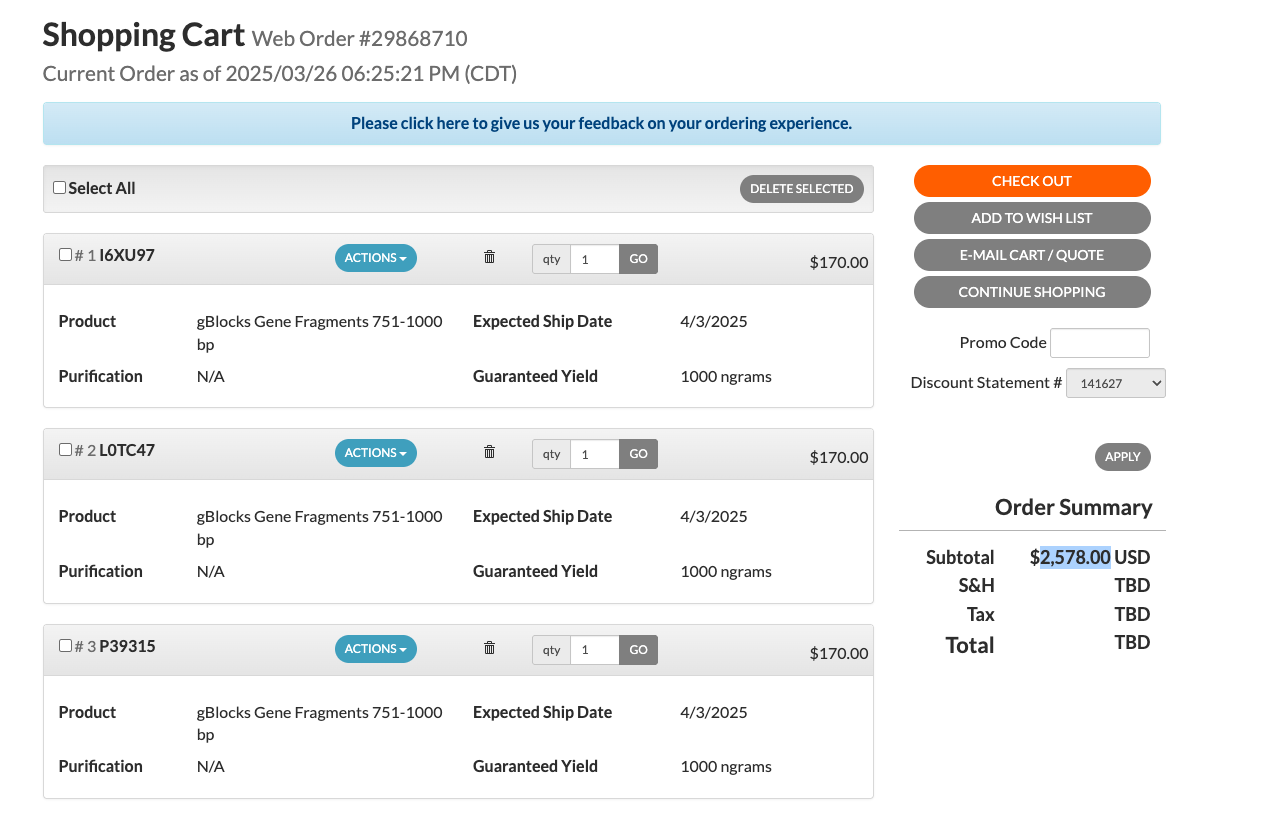

In [4]:
! pip freeze | grep oligopoolio

oligopoolio==0.0.4


In [6]:
import pandas as pd
import random
import numpy
import sys
from oligopoolio import *
SEED = 128
random.seed(SEED)
numpy.random.seed(SEED)

min_gc = 0.25
max_gc = 0.65
min_tm = 10
max_tm = 1000
min_segment_length = 90
max_segment_length = 130
max_length = 500

df = protein_all_info.copy()
# NOte you need to add in the reverse primer to the end of the sequence i.e. you add on the sequence that is the end
primer_lower = 'GATCCGGC'.lower()
os.mkdir(label)
output_directory = f'{label}/'

oligo_df = get_oligos(df, 'CodonOptimized', 'Entry', output_directory, 'gaaataattttgtttaactttaagaaggagatatacat', primer_lower, sequence_end='CTCGAGCACCACCACCACCACCACTGA',
                     min_gc=min_gc, max_gc=max_gc, min_tm=min_tm, max_tm=max_tm, min_segment_length=min_segment_length, max_segment_length=max_segment_length,
                     genbank_file="base-pet22b-base-anm.gb", insert_position=5193, simple=True, codon_optimize=False)
oligo_df.to_csv(f'{output_directory}/oligos_simple_{label}.csv', index=False)


ModuleNotFoundError: No module named 'oligopoolio'